# LDA : Reducing Dimension

# Application of LDA in Modelling

In [ ]:
import numpy as np
from sklearn.datasets import load_wine
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# 1. Load the Wine dataset


In [ ]:
wine = load_wine()
X = wine.data
y = wine.target

In [25]:
# (OPTIONAL) Create the base DataFrame with the 13 chemical features

import pandas as pd

df = pd.DataFrame(data=wine.data, columns=wine.feature_names)

# 3. Add the numeric target column (0, 1, or 2)
df["target_code"] = wine.target

# Display a sample containing rows from each class
print(df.sample(10))

# print(df['target_code'].value_counts())

     alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
17     13.83        1.57  2.62               20.0      115.0           2.95   
114    12.08        1.39  2.50               22.5       84.0           2.56   
78     12.33        0.99  1.95               14.8      136.0           1.90   
165    13.73        4.36  2.26               22.5       88.0           1.28   
79     12.70        3.87  2.40               23.0      101.0           2.83   
8      14.83        1.64  2.17               14.0       97.0           2.80   
24     13.50        1.81  2.61               20.0       96.0           2.53   
132    12.81        2.31  2.40               24.0       98.0           1.15   
161    13.69        3.26  2.54               20.0      107.0           1.83   
7      14.06        2.15  2.61               17.6      121.0           2.60   

     flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
17         3.40                  0.40            

# 2. Split into training and testing sets (80% train, 20% test)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Scale the data manually (Crucial for teaching step-by-step workflows)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Apply LDA to reduce dimensions to 2D


In [ ]:
lda = LinearDiscriminantAnalysis(n_components=2)
X_train_lda = lda.fit_transform(X_train_scaled, y_train)  # Needs 'y_train' because LDA is supervised
X_test_lda = lda.transform(X_test_scaled)

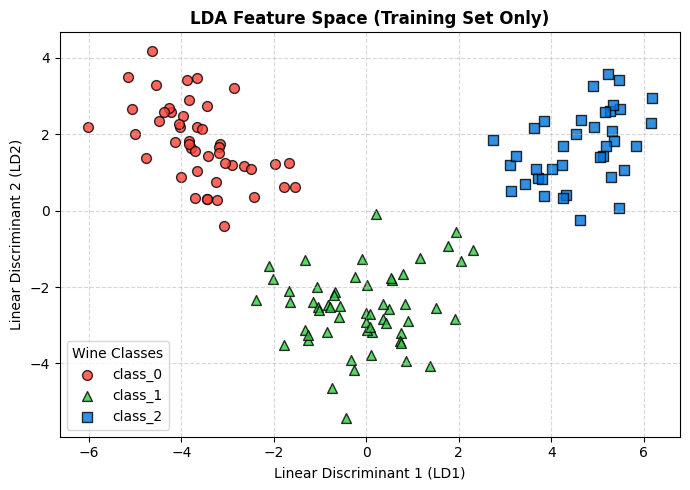

In [8]:
import matplotlib.pyplot as plt

# 1. Create the figure
plt.figure(figsize=(7, 5))

# 2. Define distinct colors and markers for the three wine classes
colors = ["#FF4136", "#2ECC40", "#0074D9"]  # Red, Green, Blue
markers = ["o", "^", "s"]  # Circle, Triangle, Square
target_names = wine.target_names

# 3. Loop through each class and plot its training points
for category, color, marker in zip(range(3), colors, markers):
    # Create a boolean mask to isolate the current class
    class_mask = y_train == category

    plt.scatter(
        X_train_lda[class_mask, 0],
        X_train_lda[class_mask, 1],
        c=color,
        marker=marker,
        edgecolor="k",
        alpha=0.8,
        s=50,  # Marker size
        label=target_names[category],
    )

# 4. Add labels, grid, and legend
plt.title("LDA Feature Space (Training Set Only)", fontsize=12, fontweight="bold")
plt.xlabel("Linear Discriminant 1 (LD1)", fontsize=10)
plt.ylabel("Linear Discriminant 2 (LD2)", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Wine Classes", loc="best")

# 5. Render the plot
plt.tight_layout()
plt.show()


# 5. Train the Logistic Regression classifier on the 2D LDA features

In [2]:
model = LogisticRegression(random_state=42)
model.fit(X_train_lda, y_train)

LogisticRegression(random_state=42)

# 6. Evaluate the model using the processed test data

In [6]:
accuracy = model.score(X_test_lda, y_test)
print(f"Model Accuracy on Test Set: {accuracy * 100:.2f}%")

Model Accuracy on Test Set: 97.22%


# Predict a new unseen wine sample 
### (Must pass through the exact same sequential transformations)

In [12]:
# Lets pick a sample
print(list(X[0]))
print(y[0])

[14.23, 1.71, 2.43, 15.6, 127.0, 2.8, 3.06, 0.28, 2.29, 5.64, 1.04, 3.92, 1065.0]
0


In [7]:

new_wine_sample = np.array(
    [[14.23, 1.71, 2.43, 15.6, 127.0, 2.8, 3.06, 0.28, 2.29, 5.64, 1.04, 3.92, 1065.0]]
) # =X[0], actual y[0] = 0

# Step A: Scale the new sample
new_sample_scaled = scaler.transform(new_wine_sample)

# Step B: Project the new sample into the 2D LDA space
new_sample_lda = lda.transform(new_sample_scaled)

# Step C: Make the final prediction
predicted_class = model.predict(new_sample_lda)
print(f"Predicted Cultivator: Class {predicted_class[0]} ({wine.target_names[predicted_class[0]]})")


Predicted Cultivator: Class 0 (class_0)
